# MLS Goalkeeper & Match Analysis
**Datasets:** `all_goalkeepers.csv` — season-level goalkeeper stats (1996–2020) | `matches.csv` — individual match results (1996–2020)

**Project Sections:**
1. Setup & Data Loading
2. SQL Analysis (SQLite — 10+ queries)
3. Python EDA (4+ charts, 3+ tables, groupby, apply/map)
4. Predictive Modeling (2 models + metrics)

---
## Part 1 — Setup & Data Loading

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [40]:
# ── Load raw CSVs ──────────────────────────────────────────────────────────────
gk = pd.read_csv('/Users/zhuoyutan/Desktop/uchicago/data analysis/final project/all_goalkeepers.csv')
matches = pd.read_csv('/Users/zhuoyutan/Desktop/uchicago/data analysis/final project/matches.csv', low_memory=False)

# Strip BOM from matches column name if present
matches.columns = matches.columns.str.lstrip('\ufeff')

# Trim whitespace from Club abbreviations
gk['Club'] = gk['Club'].str.strip()

print(f'Goalkeepers: {gk.shape[0]} rows × {gk.shape[1]} cols')
print(f'Matches:     {matches.shape[0]} rows × {matches.shape[1]} cols')

gk.head(3)

# ── Filter both datasets to 2012 and later ──────────────────────────────────
gk      = gk[gk['Year'] >= 2012].reset_index(drop=True)
matches = matches[matches['year'] >= 2012].reset_index(drop=True)
print(f'After 2012 filter — Goalkeepers: {gk.shape[0]} rows | Matches: {matches.shape[0]} rows')


Goalkeepers: 2006 rows × 19 cols
Matches:     7289 rows × 209 cols
After 2012 filter — Goalkeepers: 989 rows | Matches: 4025 rows


In [41]:
# ── Build a club abbreviation → full-name mapping ──────────────────────────────
club_map = {
    'DAL': 'Dallas',
    'MET': 'MetroStars',
    'TB':  'Tampa Bay',
    'LA':  'LA Galaxy',
    'KC':  'KC Wiz',
    'COL': 'Colorado',
    'SJ':  'San Jose',
    'NE':  'New England',
    'DC':  '.',
    'CLB': 'Columbus',
    'CHI': 'Chicago',
    'MIA': 'Miami',
    'RSL': 'Real Salt Lake',
    'ATL': 'Atlanta United',
    'CHV': 'Chivas USA',
    'HOU': 'Houston',
    'NY':  'New York Red Bulls',
    'TOR': 'Toronto FC',
    'SEA': 'Seattle Sounders',
    'NYC': 'NYCFC',
    'POR': 'Portland',
    'VAN': 'Vancouver',
    'MTL': 'Montreal',
    'SKC': 'Sporting KC',
    'ORL': 'Orlando City',
    'NYRB':'New York Red Bulls',
    'MN': 'Minnesota United',
    'LAFC':'LAFC',
    'CIN': 'FC Cincinnati',
    'NAS': 'Nashville SC',
    'IFC': 'Inter Miami',
}

gk['Club_Full'] = gk['Club'].map(club_map).fillna(gk['Club'])
print('Mapping applied. Sample:')
gk[['Club','Club_Full','Year']].drop_duplicates().head(8)

Mapping applied. Sample:


,Club,Club_Full,Year
0,KC,KC Wiz,2012
1,MTL,Montreal,2012
2,CLB,Columbus,2012
3,HOU,Houston,2012
4,SJ,San Jose,2012
5,COL,Colorado,2012
6,CHV,Chivas USA,2012
7,RSL,Real Salt Lake,2012


In [42]:
# ── Basic data-type cleanup ────────────────────────────────────────────────────
# Convert attendance in matches to numeric (has commas)
matches['attendance_num'] = (
    matches['attendance'].astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Ensure numeric score columns
matches['home_score'] = pd.to_numeric(matches['home_score'], errors='coerce')
matches['away_score'] = pd.to_numeric(matches['away_score'], errors='coerce')

# Total goals per match
matches['total_goals'] = matches['home_score'] + matches['away_score']

# Win-loss label for GK (1 = winning record, 0 = not)
gk['winning_record'] = (gk['W'] > gk['L']).astype(int)

print('Dtypes cleaned. GK winning_record distribution:')
print(gk['winning_record'].value_counts())

Dtypes cleaned. GK winning_record distribution:
winning_record
0    800
1    189
Name: count, dtype: int64


In [43]:
missing_info = pd.DataFrame({
    'Column': gk.columns[gk.isnull().any()],
    'Missing_Count': gk.isnull().sum()[gk.isnull().sum() > 0].values
})

missing_info

,Column,Missing_Count
0,Club,339
1,Club_Full,339


In [44]:
missing_info = pd.DataFrame({
    'Column': matches.columns[matches.isnull().any()],
    'Missing_Count': matches.isnull().sum()[matches.isnull().sum() > 0].values
})

missing_info

,Column,Missing_Count
0,attendance,371
1,venue,15
2,referee,4025
3,home_goal_minutes,711
4,home_goal_scorers,711
...,...,...
106,away_bench_13_minute,4025
107,away_bench_14_num,4025
108,away_bench_14,4025
109,away_bench_14_minute,4025


In [45]:
# ── Missing Value Treatment ──────────────────────────────────────────────────
# Drop rows in goalkeepers where Club or Club_Full is null
# These are players with no club assignment — not useful for analysis
print(f'GK rows before drop: {gk.shape[0]}')
gk = gk.dropna(subset=['Club', 'Club_Full']).reset_index(drop=True)
print(f'GK rows after dropping null Club/Club_Full: {gk.shape[0]}')

# Drop the referee column entirely — 100% missing after 2012 filter
if 'referee' in matches.columns:
   matches = matches.drop(columns=['referee'])
   print('Dropped: referee column (100% missing)')
print(f'Matches rows before processing: {matches.shape[0]}')

# Fill missing attendance with median

attendance_median = matches['attendance_num'].median()

matches['attendance_num'] = matches['attendance_num'].fillna(attendance_median)

print(f'Median attendance used: {attendance_median}')
print(matches['attendance_num'].isnull().sum())

print(f'Matches rows after processing: {matches.shape[0]}')
print(f'Median attendance used: {attendance_median}')

GK rows before drop: 989
GK rows after dropping null Club/Club_Full: 650
Dropped: referee column (100% missing)
Matches rows before processing: 4025
Median attendance used: 19019.5
0
Matches rows after processing: 4025
Median attendance used: 19019.5


In [46]:
#These colmns we will not using in our analysis, so we can ignore the missing values in them
print(matches.columns[matches.isnull().any()].tolist())

['attendance', 'venue', 'home_goal_minutes', 'home_goal_scorers', 'away_goal_minutes', 'away_goal_scorers', 'home_bench_6_num', 'home_bench_6', 'home_bench_6_minute', 'home_bench_7_num', 'home_bench_7', 'home_bench_7_minute', 'home_bench_8_num', 'home_bench_8', 'home_bench_8_minute', 'home_bench_9_num', 'home_bench_9', 'home_bench_9_minute', 'away_starting_11_num', 'away_starting_11', 'away_bench_5_num', 'away_bench_5', 'away_bench_5_minute', 'away_bench_6_num', 'away_bench_6', 'away_bench_6_minute', 'away_bench_7_num', 'away_bench_7', 'away_bench_7_minute', 'away_bench_8_num', 'away_bench_8', 'away_bench_8_minute', 'away_bench_9_num', 'away_bench_9', 'away_bench_9_minute', 'home_bench_10_num', 'home_bench_10', 'home_bench_10_minute', 'home_starting_12_num', 'home_starting_12', 'home_starting_13_num', 'home_starting_13', 'home_starting_14_num', 'home_starting_14', 'away_starting_12_num', 'away_starting_12', 'away_starting_13_num', 'away_starting_13', 'away_starting_14_num', 'away_start

In [47]:
print(gk.columns[gk.isnull().any()].tolist())

[]


---
## Part 2 — Python EDA
### 2a — Aggregate Tables

In [48]:
# ── Table 1: Descriptive statistics for key goalkeeper metrics ─────────────────
metrics = ['GP', 'MINS', 'SHTS', 'SV', 'GA', 'GAA', 'Sv%', 'W%', 'ShO']
table1 = gk[metrics].describe(percentiles=[.25, .5, .75, .90]).T
table1.columns = ['count','mean','std','min','25%','50%','75%','90%','max']
table1 = table1.round(2)
print('Table 1 — Descriptive Statistics: Key GK Metrics')
table1

Table 1 — Descriptive Statistics: Key GK Metrics


,count,mean,std,min,25%,50%,75%,90%,max
GP,650.00,9.68,12.09,0.00,0.00,3.00,20.00,32.00,34.00
MINS,650.00,862.20,1086.27,0.00,0.00,270.00,1800.00,2859.20,3060.00
SHTS,650.00,43.77,55.55,0.00,0.00,12.50,84.50,139.00,195.00
SV,650.00,29.37,37.88,0.00,0.00,7.00,56.00,92.10,141.00
GA,650.00,13.77,17.32,0.00,0.00,4.00,25.00,42.00,64.00
GAA,650.00,1.00,0.99,0.00,0.00,1.09,1.58,2.00,6.00
Sv%,650.00,40.95,32.85,0.00,0.00,57.60,68.20,74.25,100.00
W%,650.00,20.76,23.59,0.00,0.00,16.05,39.25,50.00,100.00
ShO,650.00,2.36,3.44,0.00,0.00,0.00,4.00,8.00,15.00


In [49]:
# ── Table 2: % Missing values — AFTER cleaning ──────────────────────────────
# Shows remaining missingness in the datasets post-treatment
def pct_missing(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'dataset': name, 'missing_count': miss, 'pct_missing': pct})
    return out[out['missing_count'] > 0].sort_values('pct_missing', ascending=False)

match_cols = ['home','away','year','home_score','away_score','attendance_num',
              'total_goals','venue']
miss_gk    = pct_missing(gk, 'goalkeepers')
miss_match = pct_missing(matches[match_cols], 'matches')

table2 = pd.concat([miss_gk, miss_match])
if table2.empty:
    print('No missing values remain in key columns after cleaning.')
else:
    print('Table 2 — Remaining Missing Values After Cleaning')
    display(table2)


Table 2 — Remaining Missing Values After Cleaning


,dataset,missing_count,pct_missing
venue,matches,15,0.37


In [50]:
# ── GroupBy 1: Median & mean GAA by Club  ──────────────────
table3a = (
    gk.groupby('Club_Full')[['Sv%','GAA','W%']]
    .mean()
    .sort_values('Sv%', ascending=False)
    .head(10)
    .round(3)
)

print('Top Clubs by Goalkeeper Performance')
table3a

Top Clubs by Goalkeeper Performance


,Sv%,GAA,W%
Club_Full,,,
BRA,66.70,1.29,42.90
Miami,63.45,1.27,40.59
PHI,56.20,1.32,28.28
ALG,51.90,1.40,12.50
Portland,51.40,1.41,24.62
Real Salt Lake,48.64,1.12,23.64
.,47.72,1.19,28.01
Chicago,47.16,1.29,20.07
Chivas USA,46.33,2.03,11.43


In [51]:
# ── GroupBy 2: Per-year league totals from matches ────────────────────────────
yearly_match = (
    matches.groupby('year')
    .agg(
        num_games    = ('home_score', 'count'),
        total_goals  = ('total_goals', 'sum'),
        avg_goals    = ('total_goals', 'mean'),
        avg_attend   = ('attendance_num', 'mean')
    )
    .round(2)
    .reset_index()
)
print('GroupBy 2 — Match Totals & Averages by Year')
yearly_match

GroupBy 2 — Match Totals & Averages by Year


,year,num_games,total_goals,avg_goals,avg_attend
0,2012,338,888,2.63,18964.86
1,2013,338,887,2.62,18786.34
2,2014,338,966,2.86,19348.87
3,2015,357,983,2.75,21621.51
4,2016,357,1006,2.82,21982.48
5,2017,391,1144,2.93,22311.25
6,2018,408,1299,3.18,22174.05
7,2019,421,1294,3.07,21703.23
8,2020,324,932,2.88,17460.51
9,2021,472,1313,2.78,17573.72


In [52]:
# ── GroupBy 3: Top keepers by career saves (min 5 seasons) ────────────────────
career = (
    gk[gk['Season'] == 'reg']
    .groupby('Player')
    .agg(
        seasons      = ('Year', 'nunique'),
        total_gp     = ('GP', 'sum'),
        total_saves  = ('SV', 'sum'),
        total_ga     = ('GA', 'sum'),
        total_shutouts = ('ShO', 'sum'),
        career_wins  = ('W', 'sum')
    )
    .reset_index()
)
career['career_save_pct'] = (
    career['total_saves'] / (career['total_saves'] + career['total_ga']) * 100
).round(2)

top_career = career[career['seasons'] >= 5].sort_values('career_save_pct', ascending=False).head(20)

print('GroupBy 3 — Career Stats for Keepers with 5+ Seasons')
top_career

GroupBy 3 — Career Stats for Keepers with 5+ Seasons


,Player,seasons,total_gp,total_saves,total_ga,total_shutouts,career_wins,career_save_pct
23,Bill Hamid,9,212,777,267,62,80,74.43
144,Matt Turner,5,69,238,93,16,24,71.90
176,Stefan Frei,9,221,677,267,63,106,71.72
168,Ryan Meara,9,36,120,48,7,16,71.43
183,Tim Melia,9,173,530,217,52,73,70.95
178,Steve Clark,7,160,542,228,37,66,70.39
152,Nick Rimando,8,226,644,275,67,102,70.08
171,Sean Johnson,9,251,779,336,57,101,69.87
191,Tyler Miller,5,68,206,89,20,38,69.83
34,Brian Rowe,9,105,340,148,24,33,69.67


In [53]:
# ── Table 4: apply() — Performance Tier labeling based on Sv% ─────────────────
# apply() is used to assign a categorical tier to each keeper-season
def sv_tier(sv_pct):
    if sv_pct >= 75:
        return 'Elite (≥75%)'
    elif sv_pct >= 70:
        return 'Good (70–74%)'
    elif sv_pct >= 65:
        return 'Average (65–69%)'
    else:
        return 'Below Avg (<65%)'

gk['sv_tier'] = gk['Sv%'].apply(sv_tier)

# map() — Flag whether GAA is above or below league-year median
year_median_gaa = gk.groupby('Year')['GAA'].median().to_dict()
gk['gaa_above_median'] = gk.apply(
    lambda row: 'Above' if row['GAA'] > year_median_gaa.get(row['Year'], np.nan) else 'Below',
    axis=1
)

table4 = (
    gk.groupby(['sv_tier','gaa_above_median'])
    .agg(count=('Player','count'), avg_W_pct=('W%','mean'))
    .round(2)
    .reset_index()
)
print('Table 4 — Save% Tier × GAA-vs-Median Cross-tab (using apply & map)')
table4

Table 4 — Save% Tier × GAA-vs-Median Cross-tab (using apply & map)


,sv_tier,gaa_above_median,count,avg_W_pct
0,Average (65–69%),Above,95,34.70
1,Average (65–69%),Below,16,46.28
2,Below Avg (<65%),Above,162,24.56
3,Below Avg (<65%),Below,250,0.70
4,Elite (≥75%),Above,13,26.48
5,Elite (≥75%),Below,51,48.24
6,Good (70–74%),Above,45,36.77
7,Good (70–74%),Below,18,46.72


### 2b — Charts

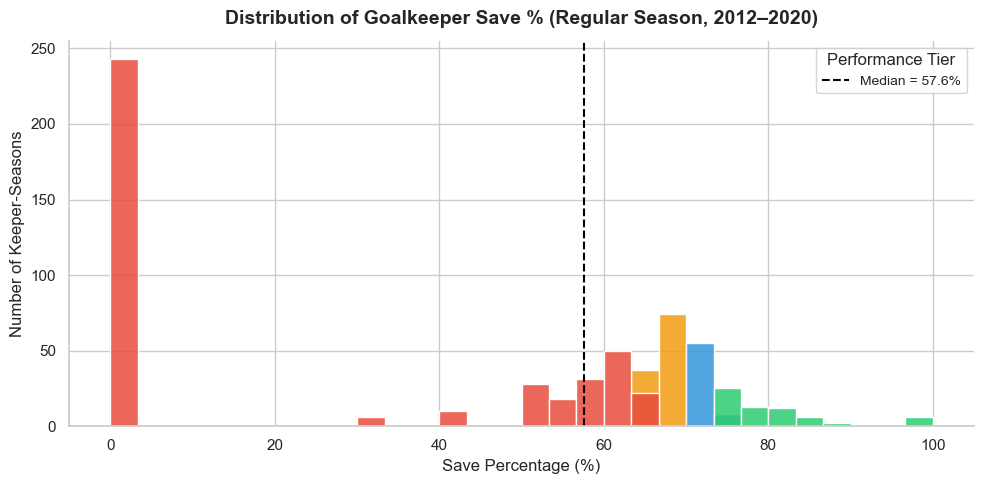

In [54]:
# ── Chart 1: Distribution of Save % (KDE + Histogram) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=gk[gk['Season'] == 'reg'],
    x='Sv%', hue='sv_tier',
    bins=30, kde=False,
    palette={'Elite (≥75%)':'#2ecc71',
             'Good (70–74%)':'#3498db',
             'Average (65–69%)':'#f39c12',
             'Below Avg (<65%)':'#e74c3c'},
    ax=ax, alpha=0.85
)

ax.axvline(gk['Sv%'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Median = {gk["Sv%"].median():.1f}%')

ax.set_title('Distribution of Goalkeeper Save % (Regular Season, 2012–2020)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Save Percentage (%)', fontsize=12)
ax.set_ylabel('Number of Keeper-Seasons', fontsize=12)
ax.legend(title='Performance Tier', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

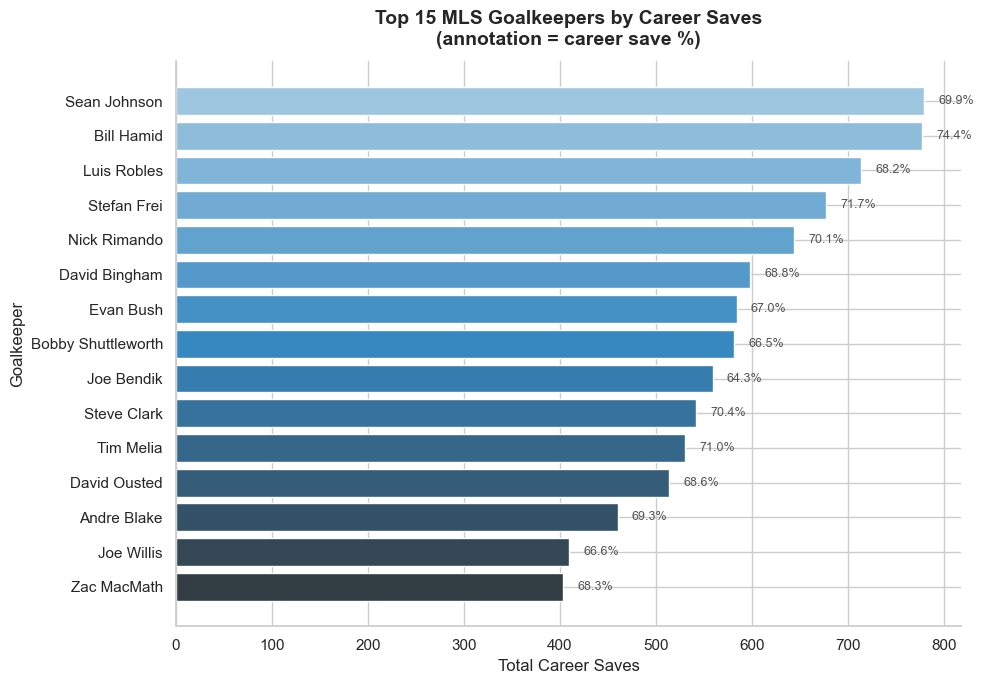

In [55]:
# ── Chart 3: Top 15 Keepers by Career Saves (Horizontal Bar) ─────────────────
top15 = career.sort_values('total_saves', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top15['Player'], top15['total_saves'],
    color=sns.color_palette('Blues_d', len(top15))
)

# Annotate save % on each bar
for bar, sv_pct in zip(bars, top15['career_save_pct']):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{sv_pct:.1f}%', va='center', ha='left', fontsize=9, color='#555')

ax.set_xlabel('Total Career Saves', fontsize=12)
ax.set_ylabel('Goalkeeper', fontsize=12)
ax.set_title('Top 15 MLS Goalkeepers by Career Saves\n(annotation = career save %)',
             fontsize=14, fontweight='bold', pad=12)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

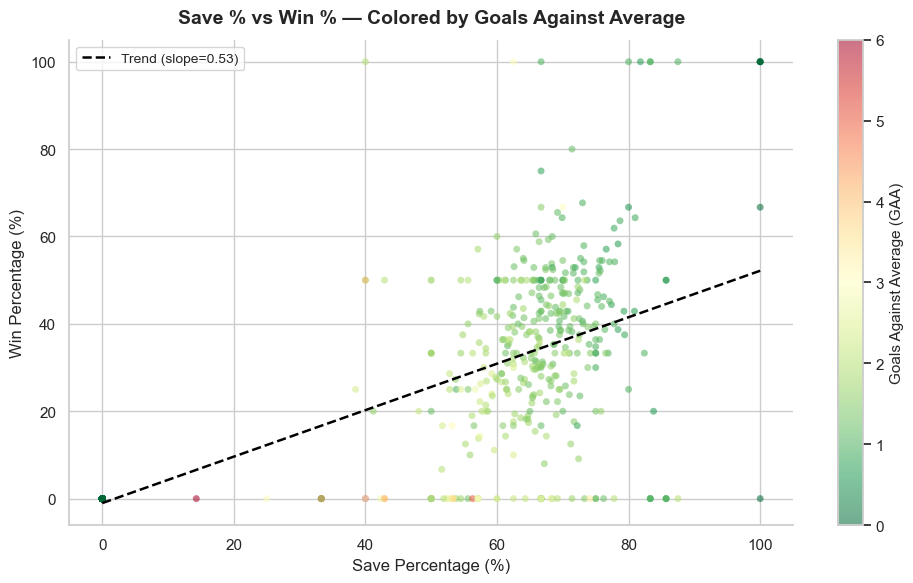

In [56]:
# ── Chart 4: Scatter — Save% vs Win% coloured by GAA tier ────────────────────
reg = gk[(gk['Season'] == 'reg') & gk['Sv%'].notna() & gk['W%'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    reg['Sv%'], reg['W%'],
    c=reg['GAA'], cmap='RdYlGn_r',
    alpha=0.55, s=25, edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Goals Against Average (GAA)', fontsize=11)

# Trend line
m, b = np.polyfit(reg['Sv%'], reg['W%'], 1)
x_line = np.linspace(reg['Sv%'].min(), reg['Sv%'].max(), 200)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8,
        linestyle='--', label=f'Trend (slope={m:.2f})')

ax.set_xlabel('Save Percentage (%)', fontsize=12)
ax.set_ylabel('Win Percentage (%)', fontsize=12)
ax.set_title('Save % vs Win % — Colored by Goals Against Average',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [57]:
# ── Chart 5 (Bonus – Plotly): Interactive — Avg Attendance & Goals per Year ───
fig = go.Figure()

fig.add_trace(go.Bar(
    x=yearly_match['year'],
    y=yearly_match['avg_attend'],
    name='Avg Attendance',
    marker_color='#3498db',
    yaxis='y1',
    opacity=0.75
))

fig.add_trace(go.Scatter(
    x=yearly_match['year'],
    y=yearly_match['avg_goals'],
    name='Avg Goals / Match',
    mode='lines+markers',
    marker=dict(color='#e74c3c', size=7),
    line=dict(width=2.5),
    yaxis='y2'
))

fig.update_layout(
    title=dict(text='MLS Average Attendance & Goals Per Match by Year (Plotly)',
               font=dict(size=16)),
    xaxis=dict(title='Year'),
    yaxis=dict(title=dict(text='Average Attendance', font=dict(color='#3498db'))),
    yaxis2=dict(title=dict(text='Avg Goals / Match', font=dict(color='#e74c3c')),
                overlaying='y', side='right'),
    legend=dict(x=0.02, y=0.95),
    template='plotly_white',
    height=450
)
fig.show()

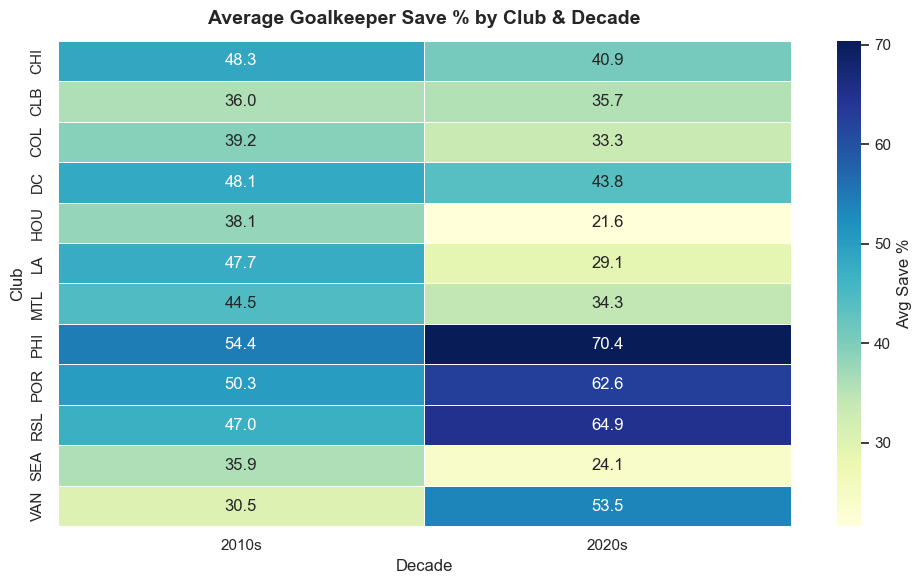

In [58]:
# ── Chart 6 (Bonus): Heatmap — Avg Save % by Club × Decade ──────────────────
gk['Decade'] = (gk['Year'] // 10 * 10).astype(str) + 's'

top_clubs = gk['Club'].value_counts().head(12).index.tolist()
heatmap_df = (
    gk[(gk['Season'] == 'reg') & gk['Club'].isin(top_clubs)]
    .groupby(['Club', 'Decade'])['Sv%']
    .mean()
    .unstack('Decade')
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt='.1f', cmap='YlGnBu',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Avg Save %'},
    ax=ax
)
ax.set_title('Average Goalkeeper Save % by Club & Decade',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Club', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3 — SQL Analysis (SQLite)
We load both tables into an in-memory SQLite database and run 10+ queries covering:
- Basic aggregation & filtering
- JOINs (3+)
- Window functions (2+)
- GROUP BY / ROLLUP (2+)
- Subqueries — CTE & inline (2+)

In [59]:
# ── Load DataFrames into SQLite ────────────────────────────────────────────────
conn = sqlite3.connect(':memory:')
gk.to_sql('goalkeepers', conn, index=False, if_exists='replace')
matches.to_sql('matches', conn, index=False, if_exists='replace')
print('Tables loaded into SQLite:', [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()])

Tables loaded into SQLite: ['goalkeepers', 'matches']


In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 1 — Basic overview: count rows and seasons in each table.
# WHY: Verify data loaded correctly and understand temporal coverage.
# HOW: Simple COUNT + MIN/MAX aggregation on each table.
# ─────────────────────────────────────────────────────────────────────────────
q1 = pd.read_sql_query("""
    SELECT
        'goalkeepers' AS table_name,
        COUNT(*)        AS total_rows,
        MIN(Year)       AS first_year,
        MAX(Year)       AS last_year,
        COUNT(DISTINCT Club) AS unique_clubs
    FROM goalkeepers
    UNION ALL
    SELECT
        'matches',
        COUNT(*),
        MIN(year),
        MAX(year),
        COUNT(DISTINCT home)
    FROM matches
""", conn)
print('Query 1 — Dataset Overview')
q1

Query 1 — Dataset Overview


,table_name,total_rows,first_year,last_year,unique_clubs
0,goalkeepers,650,2012,2020,34
1,matches,4025,2012,2022,33


In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 2 — GROUP BY: Average goalkeeper metrics by year (regular season only).
# WHY: Identify whether defensive play has improved over MLS history.
# HOW: GROUP BY Year, compute AVG on key performance indicators.
# ─────────────────────────────────────────────────────────────────────────────
q2 = pd.read_sql_query("""
    SELECT
        Year,
        COUNT(*)              AS num_keepers,
        ROUND(AVG(GAA), 3)    AS avg_GAA,
        ROUND(AVG("Sv%"), 2)  AS avg_save_pct,
        ROUND(AVG(ShO), 2)    AS avg_shutouts,
        ROUND(AVG("W%"), 2)   AS avg_win_pct
    FROM goalkeepers
    WHERE Season = 'reg'
    GROUP BY Year
    ORDER BY Year
""", conn)
print('Query 2 — Avg GK Metrics by Year (regular season)')
q2.head(10)

Query 2 — Avg GK Metrics by Year (regular season)


,Year,num_keepers,avg_GAA,avg_save_pct,avg_shutouts,avg_win_pct
0,2012,62,0.93,44.25,2.68,20.01
1,2013,64,0.91,42.19,2.78,21.14
2,2014,63,0.94,38.31,2.48,18.77
3,2015,66,0.95,43.56,2.68,22.41
4,2016,66,1.02,42.70,2.53,19.68
5,2017,75,1.21,39.93,2.52,21.17
6,2018,79,1.06,39.77,2.11,20.84
7,2019,82,0.98,38.76,2.26,21.47
8,2020,93,1.00,40.36,1.59,20.88


In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 3 — GROUP BY: Goals allowed and saves per club across all years.
# WHY: Spot which franchises have historically been strong or weak defensively.
# HOW: GROUP BY Club, SUM goals-allowed and saves, compute overall save%.
# ─────────────────────────────────────────────────────────────────────────────
q3 = pd.read_sql_query("""
    SELECT
        Club,
        COUNT(DISTINCT Year)              AS seasons,
        SUM(GA)                           AS total_goals_allowed,
        SUM(SV)                           AS total_saves,
        ROUND(SUM(SV) * 100.0 /
              NULLIF(SUM(SV) + SUM(GA), 0), 2) AS career_save_pct,
        SUM(ShO)                          AS total_shutouts
    FROM goalkeepers
    WHERE Season = 'reg'
    GROUP BY Club
    ORDER BY career_save_pct DESC
""", conn)
print('Query 3 — Career Defensive Stats by Club')
q3

Query 3 — Career Defensive Stats by Club


,Club,seasons,total_goals_allowed,total_saves,career_save_pct,total_shutouts
0,SEA,9,339,865,71.84,82
1,MIN,5,165,407,71.15,37
2,DC,9,472,1144,70.79,88
3,NE,9,228,541,70.35,38
4,KC,5,108,253,70.08,42
5,RBNY,9,63,145,69.71,8
6,POR,9,575,1307,69.45,97
7,SKC,9,278,625,69.21,55
8,ORL,9,216,484,69.14,33
9,DAL,9,302,667,68.83,64


In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 4 — JOIN: Attach goalkeeper save% to matches where they were
#           the home or away keeper's club in the same year.
# WHY: Link match-level outcomes to the keeper's season performance.
# HOW: INNER JOIN goalkeepers to matches on Club_Full = home AND Year = year;
#      repeat for away side, then UNION ALL.
# ─────────────────────────────────────────────────────────────────────────────
q4 = pd.read_sql_query("""
    SELECT
        g.Player,
        g.Club,
        g.Year,
        ROUND(g."Sv%", 2)   AS save_pct,
        m.home,
        m.away,
        m.home_score,
        m.away_score,
        'home' AS side
    FROM goalkeepers g
    INNER JOIN matches m
        ON g.Club_Full = m.home
        AND g.Year    = m.year

    UNION ALL

    SELECT
        g.Player,
        g.Club,
        g.Year,
        ROUND(g."Sv%", 2),
        m.home,
        m.away,
        m.home_score,
        m.away_score,
        'away'
    FROM goalkeepers g
    INNER JOIN matches m
        ON g.Club_Full = m.away
        AND g.Year    = m.year
    LIMIT 100
""", conn)
print(f'Query 4 — GK–Match JOIN ({len(q4)} preview rows)')
q4.head(8)

Query 4 — GK–Match JOIN (100 preview rows)


,Player,Club,Year,save_pct,home,away,home_score,away_score,side
0,Dan Kennedy,CHV,2012,65.30,Chivas USA,Chicago Fire FC,1,2,home
1,Dan Kennedy,CHV,2012,65.30,Chivas USA,Colorado Rapids,0,2,home
2,Dan Kennedy,CHV,2012,65.30,Chivas USA,FC Dallas,1,1,home
3,Dan Kennedy,CHV,2012,65.30,Chivas USA,Houston Dynamo,0,1,home
4,Dan Kennedy,CHV,2012,65.30,Chivas USA,LA Galaxy,0,4,home
5,Dan Kennedy,CHV,2012,65.30,Chivas USA,LA Galaxy,1,0,home
6,Dan Kennedy,CHV,2012,65.30,Chivas USA,Montreal Impact,2,1,home
7,Dan Kennedy,CHV,2012,65.30,Chivas USA,Philadelphia Union,0,1,home


In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 5 — JOIN: Average attendance per year joined with avg goals per match.
# WHY: Understand whether higher-scoring games drive attendance.
# HOW: Sub-aggregate matches by year, JOIN to goalkeeper year summary.
# ─────────────────────────────────────────────────────────────────────────────
q5 = pd.read_sql_query("""
    SELECT
        m.year,
        ROUND(AVG(m.attendance_num), 0)       AS avg_attendance,
        ROUND(AVG(m.home_score + m.away_score), 2) AS avg_goals_per_match,
        ROUND(g.avg_save_pct, 2)              AS avg_keeper_save_pct
    FROM matches m
    LEFT JOIN (
        SELECT Year, AVG("Sv%") AS avg_save_pct
        FROM goalkeepers
        WHERE Season = 'reg'
        GROUP BY Year
    ) g ON m.year = g.Year
    WHERE m.home_score IS NOT NULL
    GROUP BY m.year
    ORDER BY m.year
""", conn)
print('Query 5 — Attendance × Goals × Save% by Year (JOIN)')
q5.head(10)

Query 5 — Attendance × Goals × Save% by Year (JOIN)


,year,avg_attendance,avg_goals_per_match,avg_keeper_save_pct
0,2012,18965.00,2.63,44.25
1,2013,18786.00,2.62,42.19
2,2014,19349.00,2.86,38.31
3,2015,21622.00,2.75,43.56
4,2016,21982.00,2.82,42.70
5,2017,22311.00,2.93,39.93
6,2018,22174.00,3.18,39.77
7,2019,21703.00,3.07,38.76
8,2020,17461.00,2.88,40.36
9,2021,17574.00,2.78,NaN


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 6 — JOIN + aggregate: Top home vs away win rates by club.
# WHY: Quantify home-field advantage in MLS history.
# HOW: JOIN home & away results for each club, compute win rates.
# ─────────────────────────────────────────────────────────────────────────────
q6 = pd.read_sql_query("""
    SELECT
        club,
        SUM(home_games)  AS home_games,
        SUM(home_wins)   AS home_wins,
        ROUND(100.0 * SUM(home_wins) / NULLIF(SUM(home_games), 0), 1) AS home_win_pct,
        SUM(away_games)  AS away_games,
        SUM(away_wins)   AS away_wins,
        ROUND(100.0 * SUM(away_wins) / NULLIF(SUM(away_games), 0), 1) AS away_win_pct
    FROM (
        -- Home side
        SELECT
            home AS club,
            COUNT(*) AS home_games,
            SUM(CASE WHEN home_score > away_score THEN 1 ELSE 0 END) AS home_wins,
            0 AS away_games, 0 AS away_wins
        FROM matches
        WHERE home_score IS NOT NULL
        GROUP BY home

        UNION ALL

        -- Away side
        SELECT
            away AS club,
            0, 0,
            COUNT(*),
            SUM(CASE WHEN away_score > home_score THEN 1 ELSE 0 END)
        FROM matches
        WHERE away_score IS NOT NULL
        GROUP BY away
    )
    GROUP BY club
    HAVING SUM(home_games) >= 20
    ORDER BY home_win_pct DESC
    LIMIT 15
""", conn)
print('Query 6 — Home vs Away Win % by Club')
q6

Query 6 — Home vs Away Win % by Club


,club,home_games,home_wins,home_win_pct,away_games,away_wins,away_win_pct
0,Seattle Sounders FC,197,124,62.90,188,60,31.90
1,New York Red Bulls,183,111,60.70,191,59,30.90
2,LAFC,79,47,59.50,70,25,35.70
3,Atlanta United FC,98,57,58.20,90,28,31.10
4,New York City FC,131,74,56.50,130,42,32.30
5,Columbus Crew SC,159,89,56.00,156,35,22.40
6,Real Salt Lake,181,101,55.80,186,46,24.70
7,CF Montréal,27,15,55.60,27,7,25.90
8,FC Dallas,182,100,54.90,180,37,20.60
9,LA Galaxy,186,101,54.30,181,48,26.50


In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 7 — WINDOW FUNCTION: Rank goalkeepers by Save% within each year.
# WHY: Identify the best keeper per season without losing other rows.
# HOW: RANK() OVER (PARTITION BY Year ORDER BY Sv% DESC) — window function.
# ─────────────────────────────────────────────────────────────────────────────
q7 = pd.read_sql_query("""
    SELECT
        Year,
        Player,
        Club,
        ROUND("Sv%", 2)   AS save_pct,
        GP,
        GA,
        ShO,
        RANK() OVER (
            PARTITION BY Year
            ORDER BY "Sv%" DESC
        ) AS season_rank
    FROM goalkeepers
    WHERE Season = 'reg'
      AND GP >= 10
    ORDER BY Year, season_rank
""", conn)

# Show only the #1 keeper each year
best_per_year = q7[q7['season_rank'] == 1].reset_index(drop=True)
print('Query 7 — Best Keeper (by Save%) Each Season (min 10 GP)')
best_per_year

Query 7 — Best Keeper (by Save%) Each Season (min 10 GP)


,Year,Player,Club,save_pct,GP,GA,ShO,season_rank
0,2012,Bill Hamid,DC,77.90,24,24,8,1
1,2013,Matt Reis,NE,78.40,12,8,5,1
2,2014,Andy Gruenebaum,KC,75.60,11,12,3,1
3,2015,Jesse Gonzalez,DAL,78.70,11,10,5,1
4,2016,Tyler Deric,HOU,83.80,10,6,4,1
5,2017,Brad Guzan,ATL,80.90,14,10,8,1
6,2018,Bill Hamid,DC,81.00,14,12,5,1
7,2019,Steve Clark,POR,77.10,24,25,6,1
8,2020,Jimmy Maurer,DAL,79.40,16,13,7,1


In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 8 — WINDOW FUNCTION: Running total of league goals scored by year.
# WHY: Show cumulative offensive output growth as MLS expanded.
# HOW: SUM() OVER (ORDER BY year ROWS UNBOUNDED PRECEDING) — running sum.
# ─────────────────────────────────────────────────────────────────────────────
q8 = pd.read_sql_query("""
    WITH yearly AS (
        SELECT
            year,
            COUNT(*)                           AS num_matches,
            SUM(home_score + away_score)        AS total_goals
        FROM matches
        WHERE home_score IS NOT NULL
        GROUP BY year
    )
    SELECT
        year,
        num_matches,
        total_goals,
        ROUND(CAST(total_goals AS REAL) / num_matches, 2) AS goals_per_match,
        SUM(total_goals) OVER (
            ORDER BY year
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_goals
    FROM yearly
    ORDER BY year
""", conn)
print('Query 8 — Running Total of League Goals by Year (Window Function)')
q8

Query 8 — Running Total of League Goals by Year (Window Function)


,year,num_matches,total_goals,goals_per_match,cumulative_goals
0,2012,338,888,2.63,888
1,2013,338,887,2.62,1775
2,2014,338,966,2.86,2741
3,2015,357,983,2.75,3724
4,2016,357,1006,2.82,4730
5,2017,391,1144,2.93,5874
6,2018,408,1299,3.18,7173
7,2019,421,1294,3.07,8467
8,2020,324,932,2.88,9399
9,2021,472,1313,2.78,10712


In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 9 — SUBQUERY (inline): Keepers with above-average Save% for their year.
# WHY: Find overachieving keepers relative to the league standard.
# HOW: Inline subquery in WHERE clause computes per-year avg save%.
# ─────────────────────────────────────────────────────────────────────────────
q9 = pd.read_sql_query("""
    SELECT
        g.Player,
        g.Club,
        g.Year,
        ROUND(g."Sv%", 2)        AS save_pct,
        ROUND(avg.avg_sv, 2)     AS league_avg_sv,
        ROUND(g."Sv%" - avg.avg_sv, 2) AS above_avg_by
    FROM goalkeepers g
    JOIN (
        SELECT Year, AVG("Sv%") AS avg_sv
        FROM goalkeepers
        WHERE Season = 'reg' AND GP >= 10
        GROUP BY Year
    ) avg ON g.Year = avg.Year
    WHERE g.Season = 'reg'
      AND g.GP     >= 10
      AND g."Sv%"  > avg.avg_sv
    ORDER BY above_avg_by DESC
    LIMIT 20
""", conn)
print('Query 9 — Keepers with Above-Average Save% (Inline Subquery)')
q9

Query 9 — Keepers with Above-Average Save% (Inline Subquery)


,Player,Club,Year,save_pct,league_avg_sv,above_avg_by
0,Tyler Deric,HOU,2016,83.80,68.46,15.34
1,Bill Hamid,DC,2018,81.00,66.91,14.09
2,Brad Guzan,ATL,2017,80.90,66.90,14.00
3,Jimmy Maurer,DAL,2020,79.40,67.25,12.15
4,Jesse Gonzalez,DAL,2015,78.70,67.16,11.54
5,Tim Melia,SKC,2017,78.40,66.90,11.50
6,Andre Blake,PHI,2020,77.80,67.25,10.55
7,Steve Clark,POR,2019,77.10,66.72,10.38
8,Stefan Frei,SEA,2015,77.10,67.16,9.94
9,Bill Hamid,DC,2012,77.90,68.09,9.81


In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 10 — CTE (subquery style): Best career save% among keepers
#            who played ≥5 seasons and ≥100 games.
# WHY: Identify all-time elite keepers on a large enough sample.
# HOW: CTE aggregates career totals; outer query filters and ranks.
# ─────────────────────────────────────────────────────────────────────────────
q10 = pd.read_sql_query("""
    WITH career AS (
        SELECT
            Player,
            COUNT(DISTINCT Year)            AS seasons_played,
            SUM(GP)                         AS career_gp,
            SUM(SV)                         AS career_saves,
            SUM(GA)                         AS career_ga,
            SUM(ShO)                        AS career_shutouts,
            SUM(W)                          AS career_wins,
            ROUND(
                SUM(SV) * 100.0 / NULLIF(SUM(SV) + SUM(GA), 0)
            , 2)                            AS career_save_pct
        FROM goalkeepers
        WHERE Season = 'reg'
        GROUP BY Player
    )
    SELECT *
    FROM career
    WHERE seasons_played >= 5
      AND career_gp      >= 100
    ORDER BY career_save_pct DESC
    LIMIT 20
""", conn)
print('Query 10 — All-Time Best Keepers (CTE, ≥5 seasons, ≥100 GP)')
q10

Query 10 — All-Time Best Keepers (CTE, ≥5 seasons, ≥100 GP)


,Player,seasons_played,career_gp,career_saves,career_ga,career_shutouts,career_wins,career_save_pct
0,Bill Hamid,9,212,777,267,62,80,74.43
1,Stefan Frei,9,221,677,267,63,106,71.72
2,Tim Melia,9,173,530,217,52,73,70.95
3,Steve Clark,7,160,542,228,37,66,70.39
4,Nick Rimando,8,226,644,275,67,102,70.08
5,Sean Johnson,9,251,779,336,57,101,69.87
6,Brian Rowe,9,105,340,148,24,33,69.67
7,Andre Blake,7,145,460,204,38,59,69.28
8,David Bingham,9,180,598,271,46,67,68.81
9,David Ousted,7,173,514,235,46,63,68.62


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 11 — GROUP BY ROLLUP simulation: Goals allowed by Club AND Season type.
# WHY: Compare regular-season vs playoff defensive performance per club.
# HOW: SQLite lacks ROLLUP; we UNION the detail and subtotal levels manually
#      to replicate GROUP BY ROLLUP(Club, Season) behavior.
# ─────────────────────────────────────────────────────────────────────────────
q11 = pd.read_sql_query("""
    -- Detail: Club × Season
    SELECT Club, Season,
           ROUND(AVG(GAA), 3) AS avg_GAA,
           SUM(GA)            AS total_GA,
           COUNT(*)           AS keeper_seasons,
           'detail'           AS rollup_level
    FROM goalkeepers
    GROUP BY Club, Season

    UNION ALL

    -- Subtotal: Club only (Season rolled up)
    SELECT Club, 'ALL',
           ROUND(AVG(GAA), 3),
           SUM(GA),
           COUNT(*),
           'club_subtotal'
    FROM goalkeepers
    GROUP BY Club

    UNION ALL

    -- Grand total
    SELECT 'ALL', 'ALL',
           ROUND(AVG(GAA), 3),
           SUM(GA),
           COUNT(*),
           'grand_total'
    FROM goalkeepers

    ORDER BY Club, Season
""", conn)
print('Query 11 — ROLLUP: Goals Allowed by Club × Season Type')
q11.head(20)

Query 11 — ROLLUP: Goals Allowed by Club × Season Type


,Club,Season,avg_GAA,total_GA,keeper_seasons,rollup_level
0,ALG,ALL,1.40,13,2,club_subtotal
1,ALG,reg,1.40,13,2,detail
2,ALL,ALL,1.00,8949,650,grand_total
3,ATL,ALL,0.89,170,18,club_subtotal
4,ATL,reg,0.89,170,18,detail
5,BRA,ALL,1.29,9,1,club_subtotal
6,BRA,reg,1.29,9,1,detail
7,CAN,ALL,0.00,0,1,club_subtotal
8,CAN,reg,0.00,0,1,detail
9,CHI,ALL,1.29,414,25,club_subtotal


In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# Query 12 — Window + JOIN: Season rank of each keeper AND their club's
#            home win rate, to see if great keepers correlate with home form.
# WHY: Combine player-level and team-level info in one analytical result.
# HOW: CTE builds home win rates from matches; second CTE ranks keepers;
#      final SELECT JOINs them on Club_Full = home team name.
# ─────────────────────────────────────────────────────────────────────────────
q12 = pd.read_sql_query("""
    WITH home_rates AS (
        SELECT
            home AS club,
            year,
            COUNT(*) AS games,
            ROUND(100.0 * SUM(CASE WHEN home_score > away_score THEN 1 ELSE 0 END)
                  / COUNT(*), 1) AS home_win_pct
        FROM matches
        WHERE home_score IS NOT NULL
        GROUP BY home, year
    ),
    ranked_keepers AS (
        SELECT
            Player, Club_Full, Year,
            ROUND("Sv%", 2) AS save_pct,
            GAA,
            RANK() OVER (PARTITION BY Year ORDER BY "Sv%" DESC) AS yr_rank
        FROM goalkeepers
        WHERE Season = 'reg' AND GP >= 10
    )
    SELECT
        rk.Player,
        rk.Club_Full,
        rk.Year,
        rk.save_pct,
        rk.GAA,
        rk.yr_rank,
        hr.home_win_pct
    FROM ranked_keepers rk
    LEFT JOIN home_rates hr
        ON rk.Club_Full = hr.club
        AND rk.Year     = hr.year
    WHERE rk.yr_rank <= 5
    ORDER BY rk.Year, rk.yr_rank
""", conn)
print('Query 12 — Top-5 Keepers per Year with Club Home Win % (Window + JOIN)')
q12.head(20)

Query 12 — Top-5 Keepers per Year with Club Home Win % (Window + JOIN)


,Player,Club_Full,Year,save_pct,GAA,yr_rank,home_win_pct
0,Bill Hamid,.,2012,77.90,1.00,1,NaN
1,Michael Gspurning,Seattle Sounders,2012,76.60,0.71,2,NaN
2,Jimmy Nielsen,KC Wiz,2012,75.50,0.79,3,NaN
3,Sean Johnson,NYCFC,2012,75.50,1.23,3,NaN
4,Brad Knighton,New England,2012,75.00,0.88,5,NaN
5,Matt Reis,New England,2013,78.40,0.67,1,NaN
6,Joe Cannon,Vancouver,2013,73.80,1.40,2,NaN
7,Nick Rimando,Real Salt Lake,2013,73.20,1.04,3,63.20
8,Donovan Ricketts,Portland,2013,73.00,0.97,4,NaN
9,Jon Busch,San Jose,2013,71.10,1.24,5,NaN


---
## Part 4 — Predictive Modeling


### Model — Logistic Regression: Predict Winning Record
**Target:** `winning_record` (1 if W > L, else 0)  
**Features:** Save %, GAA, Shutouts, Games Played, Win %

In [72]:
# ── Logistic Regression ────────────────────────────────────────────────────────
log_df = gk[(gk['Season'] == 'reg') & (gk['GP'] >= 5)].copy()
log_df = log_df[['winning_record','Sv%','GAA','ShO','GP','SHTS']].dropna()

log_df['shots_per_game'] = log_df['SHTS'] / log_df['GP']
log_df['shutout_rate']   = log_df['ShO']  / log_df['GP']

features_log = ['Sv%', 'GAA', 'shutout_rate', 'shots_per_game']
X2 = log_df[features_log]
y2 = log_df['winning_record']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

logr = LogisticRegression(max_iter=500, random_state=42)
logr.fit(X2_train_s, y2_train)
y2_pred = logr.predict(X2_test_s)

acc = accuracy_score(y2_test, y2_pred)
print('=== Logistic Regression — Predict Winning Record ===')
print(f'  Accuracy : {acc:.4f}')
print()
print(classification_report(y2_test, y2_pred, target_names=['Not Winning','Winning']))

coef_log = pd.DataFrame({'Feature': features_log, 'Coefficient': logr.coef_[0]}).sort_values('Coefficient', ascending=False)
print('Logistic Coefficients (standardized):')
print(coef_log.to_string(index=False))

=== Logistic Regression — Predict Winning Record ===
  Accuracy : 0.8136

              precision    recall  f1-score   support

 Not Winning       0.81      0.88      0.84        33
     Winning       0.83      0.73      0.78        26

    accuracy                           0.81        59
   macro avg       0.82      0.80      0.81        59
weighted avg       0.81      0.81      0.81        59

Logistic Coefficients (standardized):
       Feature  Coefficient
           Sv%         0.66
  shutout_rate         0.14
shots_per_game        -0.35
           GAA        -0.78


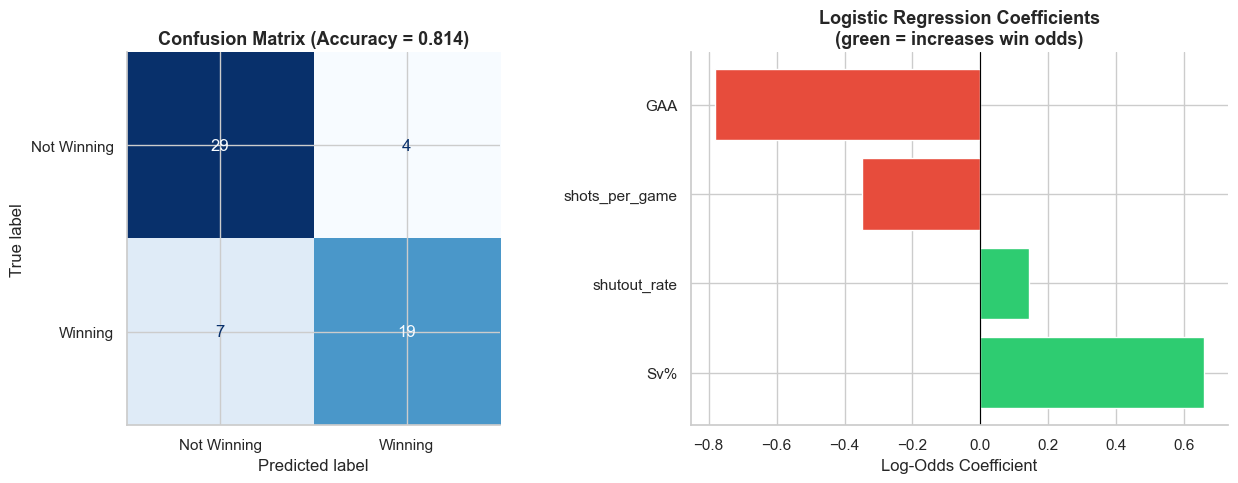

In [73]:
# ── Logistic Regression Diagnostic Plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y2_test, y2_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Winning', 'Winning'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Accuracy = {acc:.3f})',
                  fontsize=13, fontweight='bold')

# Plot B: Feature Coefficients
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_log['Coefficient']]
axes[1].barh(coef_log['Feature'], coef_log['Coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Log-Odds Coefficient', fontsize=12)
axes[1].set_title('Logistic Regression Coefficients\n(green = increases win odds)',
                  fontsize=13, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

In [74]:
# ── Model Comparison Summary ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'      : ['Logistic Regression'],
    'Target'     : ['Winning Record (binary)'],
    'Metric'     : ['Accuracy'],
    'Score'      : [f'{acc:.3f}']
})
print('Model Summary')
summary

Model Summary


,Model,Target,Metric,Score
0,Logistic Regression,Winning Record (binary),Accuracy,0.814
